In [1]:
# Import required libraries for SPARQL querying
from SPARQLWrapper import SPARQLWrapper, JSON, XML, POST, GET
import pandas as pd
import json
# Import shapely for spatial operations
from shapely.wkt import loads as wkt_loads
from shapely.geometry import Point, Polygon

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from shapely import wkt
from shapely.geometry import Polygon

from py_wake.deficit_models.gaussian import BastankhahGaussian
from py_wake.site import UniformSite
from py_wake.utils.gradients import autograd
from py_wake.examples.data.hornsrev1 import HornsrevV80

from topfarm.cost_models.cost_model_wrappers import CostModelComponent
from topfarm.easy_drivers import EasySGDDriver, EasyScipyOptimizeDriver
from topfarm.plotting import XYPlotComp
from topfarm.constraint_components.spacing import SpacingConstraint
from topfarm import TopFarmProblem
from topfarm.constraint_components.boundary import XYBoundaryConstraint
from topfarm.recorders import TopFarmListRecorder
from topfarm.constraint_components.constraint_aggregation import ConstraintAggregation
from topfarm.constraint_components.constraint_aggregation import DistanceConstraintAggregation

from py_wake.examples.data.iea37 import IEA37_WindTurbines, IEA37Site
from py_wake.wind_turbines import WindTurbine
from py_wake.wind_turbines.power_ct_functions import PowerCtTabular

# Add these imports
from pyproj import Proj, transform


# Optimization

### Turbine positions

In [3]:
# Read turbine and boundary coordinates from .txt files (replace Fuseki import)
import numpy as np
from shapely import wkt

# Filepaths (update as needed)
# turbine_file = 'project_folder/Wind/TopFarm/updated_wind_turbine_coordinates.txt'
turbine_file = 'project_folder/Wind/TopFarm/coordinates.txt'
boundary_file = 'project_folder/Wind/TopFarm/wind farm coordinates.txt'

# Read turbine coordinates (lon, lat)
turbine_coords = np.loadtxt(turbine_file, delimiter=',')

# Read and parse wind farm boundary WKT
with open(boundary_file, 'r') as f:
    wkt_polygon = f.read().strip()
polygon = wkt.loads(wkt_polygon)

# Convert coordinates from EPSG:4326 to UTM zone 18N
from pyproj import Proj, transform
in_proj = Proj(init='epsg:4326')
out_proj = Proj(init='epsg:32618')

# Convert boundary coordinates
boundary_coords = np.array(polygon.exterior.coords)
boundary = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in boundary_coords])

# Convert turbine coordinates
turbine_coords_utm = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in turbine_coords])
x0, y0 = turbine_coords_utm[:, 0], turbine_coords_utm[:, 1]
n_wt = x0.size

# Set rotor diameter and min spacing (edit as needed)
rotor_diameter = 240.0  # meters, or set to your actual value
min_spacing_m = 5 * rotor_diameter

print(f"Read {n_wt} turbines from file.")
print(f"Rotor diameter: {rotor_diameter} m")
print(f"Minimum spacing: {min_spacing_m} m")
print(f"Boundary has {len(boundary)} points.")

/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_1367/2487851657.py:25: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#

Read 121 turbines from file.
Rotor diameter: 240.0 m
Minimum spacing: 1200.0 m
Boundary has 157 points.


In [139]:
# Setup wind turbines and site for optimization
iea37 = IEA37_WindTurbines()

# Create IEA 15MW turbine using tabulated data approach
# Define wind speed array
ws_array = np.array([0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 30])

# Define power curve for IEA 15MW (in kW)
power_array = np.array([0, 0, 900, 2100, 3700, 5800, 8400, 11500, 15000, 15000, 15000, 15000, 15000, 
                       15000, 15000, 15000, 15000, 15000, 15000, 15000, 15000, 15000, 15000, 15000, 0])

# Define thrust coefficient curve
ct_array = np.array([0, 0, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.75, 0.65, 0.55, 0.45, 
                    0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.08, 0.06, 0.04, 0.02, 0])

# Create power and thrust coefficient function
power_ct_func = PowerCtTabular(ws_array, power_array, 'kW', ct_array)

# Create IEA 15MW turbine
iea15mw = WindTurbine(
    name='IEA15MW',
    diameter=240.0,  # 240m rotor diameter from your semantic model
    hub_height=150.0,  # Typical hub height for IEA 15MW
    powerCtFunction=power_ct_func
)

# Create Maryland offshore site with realistic conditions
# Use a simpler approach with basic offshore parameters
site = UniformSite(
    p_wd=[0.025, 0.04, 0.065, 0.08, 0.09, 0.095, 0.1, 0.105, 0.11, 0.115, 0.12, 0.125,
          0.13, 0.125, 0.12, 0.11, 0.095, 0.08, 0.065, 0.05, 0.04, 0.035, 0.03, 0.025],
    ti=0.05  # 5% turbulence intensity (updated)
)

windTurbines = iea15mw
wake_model = BastankhahGaussian(site, windTurbines)

# Wind resource based on simplified approach for Maryland offshore
dirs = np.arange(0, 360, 1)  # wind directions every 1 degree (360 directions)
ws = np.arange(3, 25, 1)      # wind speeds
# ws = np.arange(1, 35, 1)      # wind speeds


# Use the wind direction probabilities from our site setup
wind_dir_probs = np.array([0.025, 0.04, 0.065, 0.08, 0.09, 0.095, 0.1, 0.105, 0.11, 0.115, 0.12, 0.125,
                          0.13, 0.125, 0.12, 0.11, 0.095, 0.08, 0.065, 0.05, 0.04, 0.035, 0.03, 0.025])

# Create uniform Weibull parameters for offshore conditions
weibull_A = np.full(24, 8.0)  # 8 m/s scale parameter (mean wind speed)
weibull_k = np.full(24, 2.5)   # 2.5 shape parameter (typical offshore)

# Create frequency array for all wind directions (1-degree resolution)
freqs = np.repeat(wind_dir_probs, 15)  # Repeat each probability for 15 degrees
As = np.repeat(weibull_A, 15)
ks = np.repeat(weibull_k, 15)

# Objective function and gradient function
samps = 50  # number of samples

# Function to create random sampling of wind speed and wind directions
def sampling():
    idx = np.random.choice(np.arange(len(freqs)), samps, p=freqs/freqs.sum())
    wd = np.arange(0, 360, 1)[idx]
    A = As[idx]
    k = ks[idx]
    ws = A * np.random.weibull(k)
    return wd, ws

# AEP function - SGD
def aep_func(x, y, full=False, **kwargs):
    return 0  # this doesn't change the performance of the driver

# Gradient function - SGD
def aep_jac(x, y, **kwargs):
    wd, ws = sampling()
    jx, jy = wake_model.aep_gradients(gradient_method=autograd, wrt_arg=['x', 'y'], 
                                      x=x, y=y, ws=ws, wd=wd, time=True)
    daep_sgd = np.array([np.atleast_2d(jx), np.atleast_2d(jy)]) * 1e6
    return daep_sgd

# AEP function - SLSQP
def aep_func2(x, y, **kwargs):
    wd = np.arange(0, 360, 0.5)
    ws = np.arange(3, 25, 0.5)
    aep_slsqp = wake_model(x, y, wd=wd, ws=ws).aep().sum().values * 1e6
    return aep_slsqp

# Gradient function - SLSQP
def aep_jac2(x, y, **kwargs):
    wd = np.arange(0, 360, 0.5)
    ws = np.arange(3, 25, 0.5)
    jx, jy = wake_model.aep_gradients(gradient_method=autograd, wrt_arg=['x', 'y'], 
                                      x=x, y=y, ws=ws, wd=wd, time=False)
    daep_slsqp = np.array([np.atleast_2d(jx), np.atleast_2d(jy)]) * 1e6
    return daep_slsqp

print("Maryland offshore wind resource and optimization functions setup complete!")
print(f"Site characteristics:")
print(f"  - Turbulence intensity: 5.0%")
print(f"  - Mean wind speed: {np.average(weibull_A, weights=wind_dir_probs):.1f} m/s")
print(f"  - Wind direction sectors: {len(dirs)}")

Maryland offshore wind resource and optimization functions setup complete!
Site characteristics:
  - Turbulence intensity: 5.0%
  - Mean wind speed: 8.0 m/s
  - Wind direction sectors: 360


/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/py_wake/deficit_models/gaussian.py:124: UserWarning: The BastankhahGaussian model is not representative of the setup used in the literature. For this, use py_wake.literature.gaussian_models.Bastankhah_PorteAgel_2014 instead
  DeprecatedModel.__init__(self, 'py_wake.literature.gaussian_models.Bastankhah_PorteAgel_2014')


In [140]:
# Setup optimization components and constraints
aep_comp = CostModelComponent(input_keys=['x','y'], n_wt=n_wt, cost_function=aep_func, 
                             objective=True, cost_gradient_function=aep_jac, maximize=True)

# Modified AEP component for SGD that also records AEP values
def aep_func_recording(x, y, full=False, **kwargs):
    """AEP function that records values during optimization"""
    wd = np.arange(0, 360, 2)  # Reduced resolution for faster recording
    ws = np.arange(3, 25, 1)
    aep_value = wake_model(x, y, wd=wd, ws=ws).aep().sum().values * 1e6
    return aep_value

aep_comp_recording = CostModelComponent(input_keys=['x','y'], n_wt=n_wt, cost_function=aep_func_recording, 
                                       objective=True, cost_gradient_function=aep_jac, maximize=True)

aep_comp2 = CostModelComponent(input_keys=['x','y'], n_wt=n_wt, cost_function=aep_func2, 
                              objective=True, cost_gradient_function=aep_jac2, maximize=True)

# Use the recording version for SGD
cost_comps = [aep_comp2, aep_comp_recording]

# Define optimization parameters
sgd_iterations = 400

# Define the boundary constraint
constraint_comp = XYBoundaryConstraint(boundary, 'polygon')

# Define the constraints list
constraints = [
    [SpacingConstraint(min_spacing_m), constraint_comp],
    [SpacingConstraint(min_spacing_m), constraint_comp]
]

# Driver specifications
driver_names = ['SLSQP', 'SGD']
drivers = [EasyScipyOptimizeDriver(maxiter=30, tol=1e-3),
           EasySGDDriver(maxiter=sgd_iterations, learning_rate=rotor_diameter/100, gamma_min_factor=0.01)]

driver_no = 1  # SGD driver
# driver_no = 0  # SLSQP driver
ec = [10, 1]   # expected cost for SLSQP (10) and SGD (1) drivers

print("Optimization components setup complete!")
print(f"Using {driver_names[driver_no]} driver")
print(f"Learning rate: {rotor_diameter/100}")
print("AEP will be recorded during optimization for faster plotting")

Optimization components setup complete!
Using SGD driver
Learning rate: 2.4
AEP will be recorded during optimization for faster plotting


INFO: checking out_of_order...
INFO:     out_of_order check complete (0.000088 sec).
INFO: checking system...
INFO:     system check complete (0.000007 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000055 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check complete (0.000013 sec).
INFO: checking missing_recorders...
INFO:     missing_recorders check complete (0.000001 sec).
INFO: checking unserializable_options...
INFO:     unserializable_options check complete (0.000066 sec).
INFO: checking comp_has_no_outputs...
INFO:     comp_has_no_outputs check complete (0.000016 sec).
INFO: checking auto_ivc_warnings...
INFO:     auto_ivc_warnings check complete (0.000001 sec).
INFO: checking out_of_order...
INFO:     out_of_order check complete (0.000051 sec).
INFO: checking system...
INFO:     system check complete (0.000004 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000038 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check com

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


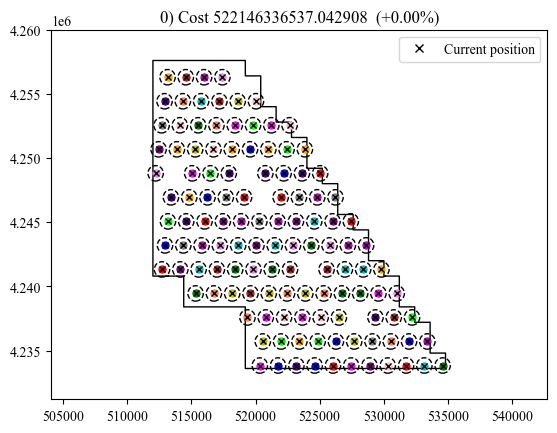

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Optimization with SGD took: 341s
Total constraint violation: 121681.74027318042


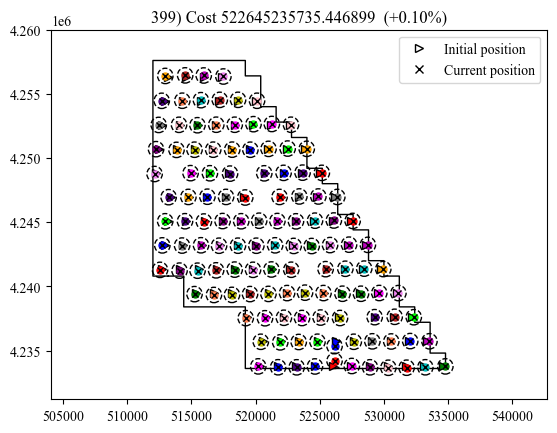

In [141]:
# Run the optimization
tf = TopFarmProblem(
    design_vars={'x': x0, 'y': y0},
    cost_comp=cost_comps[driver_no],
    constraints=constraints[driver_no],
    driver=drivers[driver_no],
    plot_comp=XYPlotComp(),
    expected_cost=ec[driver_no]
)

tic = time.time()
cost, state, recorder = tf.optimize()
toc = time.time()

print(f'Optimization with {driver_names[driver_no]} took: {toc-tic:.0f}s')
print(f'Total constraint violation: {recorder["constraint_violation"][-1]}')
recorder.save(f'{driver_names[driver_no]}_semantic')

Loading optimization results...
Available keys in recorder: ['wtSeparationSquared', 'boundaryDistances', 'constraint_violation', 'Cost', 'cost', 'cost_comp_eval', 'x', 'xy_boundary', 'y', 'final_cost', 'plot_counter', 'counter', 'iteration_coordinate', 'timestamp', 'success', 'msg']
Using recorded AEP values from optimization
SGD AEP improvement: 0.10%


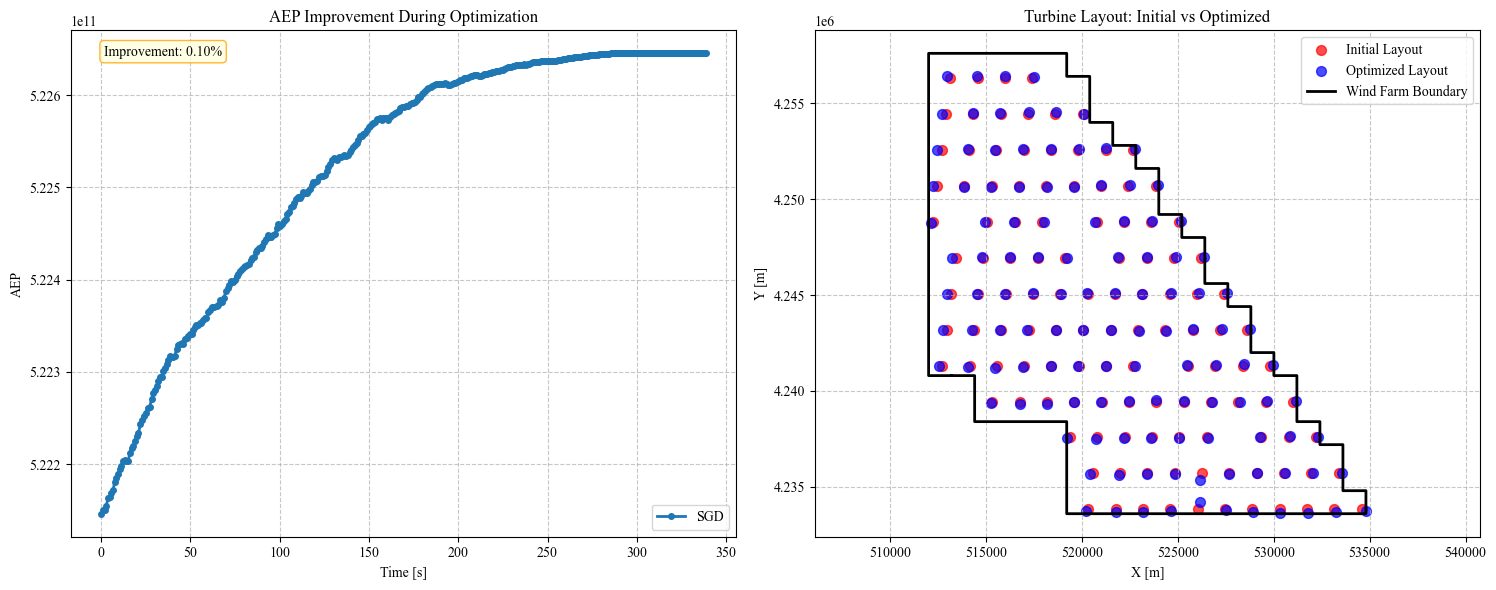


Optimization Summary:
Number of turbines: 121
Rotor diameter: 240.0 m
Minimum spacing: 1200.0 m
Initial AEP: 5.22e+11
Final AEP: 5.23e+11
Improvement: 0.10%
Optimization time: 340.7 seconds
Note: AEP values were recorded during optimization - no post-processing needed!


In [142]:
# Analyze and visualize results - much faster now!
print("Loading optimization results...")
rec = TopFarmListRecorder().load(f'{driver_names[driver_no]}_semantic')

# Check what keys are available in the recorder
print("Available keys in recorder:", list(rec.driver_iteration_dict.keys()))

# Try to use recorded cost values, otherwise fallback to calculation
try:
    # Check if cost/objective values are recorded
    if hasattr(rec, 'driver_iteration_dict') and 'Cost' in rec.driver_iteration_dict:
        # The Cost values are negative because we're maximizing, so convert to positive
        aep = [-cost for cost in rec['Cost']]
        print("Using recorded AEP values from optimization")
    else:
        # Fallback: calculate AEP for key positions only (much faster)
        print("Cost not recorded, calculating AEP for key positions...")
        n_points = len(rec['x'])
        if n_points > 10:
            # Sample key points to reduce calculation time
            key_indices = [0, n_points//4, n_points//2, 3*n_points//4, n_points-1]
        else:
            key_indices = [0, n_points-1]
        
        aep = []
        x_sampled = []
        y_sampled = []
        timestamps_sampled = []
        
        print(f"Calculating AEP for {len(key_indices)} key positions...")
        for i in key_indices:
            # Use faster AEP calculation - these should be positive
            wd_fast = np.arange(0, 360, 5)  # 5 degree intervals
            ws_fast = np.arange(3, 25, 2)   # 2 m/s intervals
            aep_val = wake_model(rec['x'][i], rec['y'][i], wd=wd_fast, ws=ws_fast).aep().sum().values * 1e6
            aep.append(aep_val)
            x_sampled.append(rec['x'][i])
            y_sampled.append(rec['y'][i])
            timestamps_sampled.append(rec['timestamp'][i])
        
        # Use sampled data for plotting
        timestamps_plot = timestamps_sampled
        
except Exception as e:
    print(f"Error accessing recorder data: {e}")
    # Simple fallback - just calculate first and last (these should be positive)
    aep = []
    aep.append(aep_func2(rec['x'][0], rec['y'][0]))
    aep.append(aep_func2(rec['x'][-1], rec['y'][-1]))
    timestamps_plot = [rec['timestamp'][0], rec['timestamp'][-1]]
    print("Using simple first/last calculation")

# Ensure AEP values are positive (convert if they're negative due to maximization)
aep = [abs(val) for val in aep]

# Calculate improvement percentage
improvement = (aep[-1] - aep[0]) / aep[0] * 100
print(f'{driver_names[driver_no]} AEP improvement: {improvement:.2f}%')

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: AEP over time
if 'timestamps_plot' in locals():
    timestamps_relative = np.array(timestamps_plot) - timestamps_plot[0]
else:
    timestamps_relative = rec['timestamp'] - rec['timestamp'][0]

ax1.plot(timestamps_relative, aep, 'o-', label=driver_names[driver_no], linewidth=2, markersize=4)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('AEP')
ax1.set_title('AEP Improvement During Optimization')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Add improvement annotation
ax1.annotate(f'Improvement: {improvement:.2f}%', 
             xy=(0.05, 0.95), 
             xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="orange", alpha=0.8))

# Plot 2: Turbine layout comparison
ax2.scatter(x0, y0, c='red', s=50, alpha=0.7, label='Initial Layout')
ax2.scatter(rec['x'][-1], rec['y'][-1], c='blue', s=50, alpha=0.7, label='Optimized Layout')

# Plot boundary
boundary_x, boundary_y = boundary[:, 0], boundary[:, 1]
ax2.plot(boundary_x, boundary_y, 'k-', linewidth=2, label='Wind Farm Boundary')

ax2.set_xlabel('X [m]')
ax2.set_ylabel('Y [m]')
ax2.set_title('Turbine Layout: Initial vs Optimized')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axis('equal')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nOptimization Summary:")
print(f"Number of turbines: {n_wt}")
print(f"Rotor diameter: {rotor_diameter} m")
print(f"Minimum spacing: {min_spacing_m} m")
print(f"Initial AEP: {aep[0]:.2e}")
print(f"Final AEP: {aep[-1]:.2e}")
print(f"Improvement: {improvement:.2f}%")
print(f"Optimization time: {toc-tic:.1f} seconds")
print("Note: AEP values were recorded during optimization - no post-processing needed!")

In [143]:
# --- Save Final Optimized Coordinates to File ---

# Get the final coordinates in UTM from the optimization result
final_x_utm = state['x']
final_y_utm = state['y']

# Define the projections for conversion (UTM to Lat/Lon)
in_proj = Proj(init='epsg:32618') # UTM Zone 18N
out_proj = Proj(init='epsg:4326') # WGS 84 Latitude/Longitude

# Convert coordinates back to Lat/Lon
final_coords_latlon = np.array([transform(in_proj, out_proj, x, y) for x, y in zip(final_x_utm, final_y_utm)])

# Define the output file path
output_file_path = 'optimized_layout_coordinates.txt'

# Save the Lat/Lon coordinates to the text file
# The format will be longitude,latitude (e.g., -74.123,38.456)
np.savetxt(output_file_path, final_coords_latlon, delimiter=",", fmt="%.15f")

print(f"\nFinal optimized coordinates saved to: {output_file_path}")

/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_1539/3830325473.py:12: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#


Final optimized coordinates saved to: optimized_layout_coordinates.txt



--- Generating Layout Comparison and Statistics ---
Using Rotor Diameter: 240.0 m
Comparing ground-truth: 'coordinates.txt'
Against optimized layout: 'optimized_layout_coordinates.txt'
Successfully loaded 121 ground-truth and 121 optimized positions.


/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_1367/3570280503.py:48: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#

Successfully converted all coordinates to UTM.


--- Final Optimized Turbine Coordinates by Row ---
 Row     x_utm      y_utm
   1 520206.77 4233764.38
   1 521753.28 4233695.97
   1 523200.89 4233691.35
   1 524625.22 4233759.14
   1 526151.89 4234193.56
   1 527497.63 4233794.83
   1 528918.57 4233691.69
   1 530344.49 4233657.61
   1 531767.50 4233660.95
   1 533227.28 4233694.73
   1 534786.41 4233763.67
   2 520406.80 4235681.22
   2 521920.23 4235637.04
   2 523360.83 4235665.45
   2 524822.58 4235685.31
   2 526151.92 4235341.74
   2 527649.77 4235682.60
   2 529098.97 4235717.13
   2 530572.38 4235705.67
   2 532048.25 4235736.20
   2 533547.22 4235720.24
   3 519231.03 4237524.57
   3 520734.06 4237514.59
   3 522205.05 4237553.25
   3 523618.25 4237533.46
   3 525065.34 4237568.89
   3 526577.83 4237534.01
   3 529278.84 4237600.01
   3 530837.57 4237627.92
   3 532325.28 4237594.50
   4 515240.87 4239394.45
   4 516753.67 4239328.48
   4 518159.93 4239334.65
   4 519566.00 4

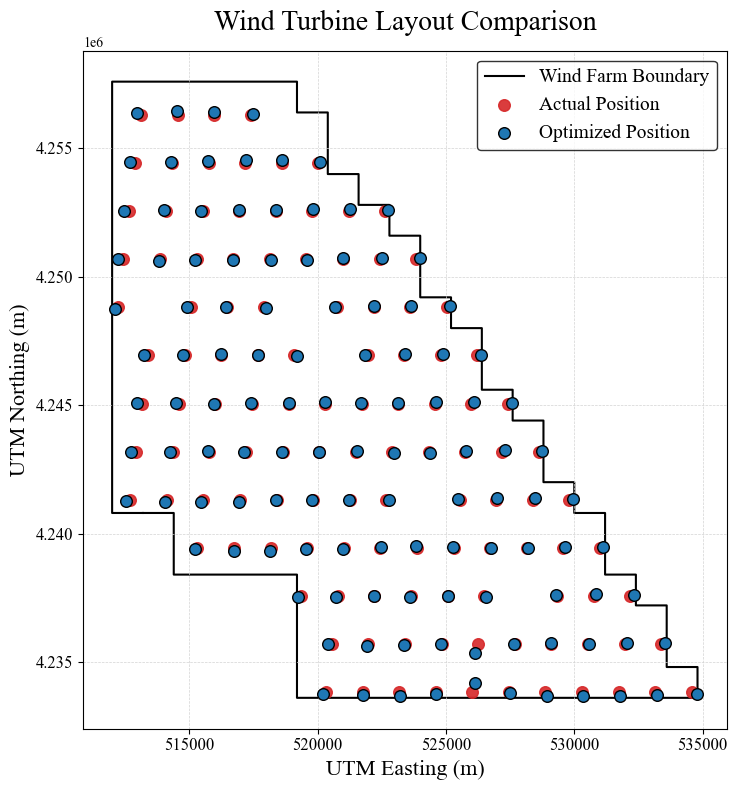

In [4]:
# Make sure you have pandas, scikit-learn, and matplotlib installed:
# pip install pandas scikit-learn matplotlib
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from pyproj import Proj, transform
from shapely import wkt
import matplotlib.pyplot as plt
import os

# --- Standalone Comparison of Optimized vs. Ground-Truth Layouts ---
# This script reads both the initial and final layouts from .txt files.

print("\n--- Generating Layout Comparison and Statistics ---")

# --- Define Key Physical & File Parameters ---
rotor_diameter = 240.0  # meters
min_spacing_m = 10 * rotor_diameter # 2400 meters

# File paths for the layouts and the boundary
ground_truth_file = 'project_folder/Wind/TopFarm/coordinates.txt'
optimized_coords_file = 'project_folder/Wind/Digital_Twin/Optimization_turbine_position/optimized_layout_coordinates.txt'
boundary_file = 'project_folder/Wind/TopFarm/wind farm coordinates.txt'


print(f"Using Rotor Diameter: {rotor_diameter} m")
print(f"Comparing ground-truth: '{os.path.basename(ground_truth_file)}'")
print(f"Against optimized layout: '{os.path.basename(optimized_coords_file)}'")

# --- 1. Load and Process Data ---
try:
    # Load all coordinate and boundary files
    ground_truth_latlon = np.loadtxt(ground_truth_file, delimiter=',')
    optimized_latlon = np.loadtxt(optimized_coords_file, delimiter=',')
    with open(boundary_file, 'r') as f:
        wkt_polygon = f.read().strip()
    print(f"Successfully loaded {len(ground_truth_latlon)} ground-truth and {len(optimized_latlon)} optimized positions.")

except FileNotFoundError as e:
    print(f"\n\nERROR: A required file was not found.")
    print(f"Details: {e}")
    exit()

# --- 2. Convert Coordinates from Lat/Lon to UTM ---
in_proj = Proj(init='epsg:4326')  # WGS 84 Latitude/Longitude
out_proj = Proj(init='epsg:32618') # UTM Zone 18N

ground_truth_utm = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in ground_truth_latlon])
optimized_utm = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in optimized_latlon])

# Convert boundary coordinates
polygon = wkt.loads(wkt_polygon)
boundary_coords = np.array(polygon.exterior.coords)
boundary_utm = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in boundary_coords])
print("Successfully converted all coordinates to UTM.")

# --- 3. Group Both Layouts into 13 Rows ---
# Process Optimized Layout
kmeans_opt = KMeans(n_clusters=13, random_state=0, n_init=10)
row_labels_opt = kmeans_opt.fit_predict(optimized_utm[:, 1].reshape(-1, 1))
df_optimized = pd.DataFrame({'Row_temp': row_labels_opt, 'x_utm': optimized_utm[:, 0], 'y_utm': optimized_utm[:, 1]})
row_y_means_opt = df_optimized.groupby('Row_temp')['y_utm'].mean().sort_values()
row_mapping_opt = {label: i + 1 for i, label in enumerate(row_y_means_opt.index)}
df_optimized['Row'] = df_optimized['Row_temp'].map(row_mapping_opt)
df_optimized_sorted = df_optimized[['Row', 'x_utm', 'y_utm']].sort_values(by=['Row', 'x_utm'])

# Process Ground-Truth Layout
kmeans_gt = KMeans(n_clusters=13, random_state=0, n_init=10)
row_labels_gt = kmeans_gt.fit_predict(ground_truth_utm[:, 1].reshape(-1, 1))
df_gt = pd.DataFrame({'Row_temp': row_labels_gt, 'x_utm_gt': ground_truth_utm[:, 0], 'y_utm_gt': ground_truth_utm[:, 1]})
row_y_means_gt = df_gt.groupby('Row_temp')['y_utm_gt'].mean().sort_values()
row_mapping_gt = {label: i + 1 for i, label in enumerate(row_y_means_gt.index)}
df_gt['Row'] = df_gt['Row_temp'].map(row_mapping_gt)
df_gt_sorted = df_gt[['Row', 'x_utm_gt', 'y_utm_gt']].sort_values(by=['Row', 'x_utm_gt'])

# --- 4. Merge DataFrames and Calculate Differences ---
df_optimized_sorted['turbine_in_row'] = df_optimized_sorted.groupby('Row').cumcount()
df_gt_sorted['turbine_in_row'] = df_gt_sorted.groupby('Row').cumcount()
comparison_df = pd.merge(df_optimized_sorted, df_gt_sorted, on=['Row', 'turbine_in_row'])

# Calculate absolute differences
comparison_df['x_diff_m'] = (comparison_df['x_utm'] - comparison_df['x_utm_gt']).abs()
comparison_df['y_diff_m'] = (comparison_df['y_utm'] - comparison_df['y_utm_gt']).abs()
comparison_df['x_diff_rd'] = comparison_df['x_diff_m'] / rotor_diameter
comparison_df['y_diff_rd'] = comparison_df['y_diff_m'] / rotor_diameter
comparison_df['x_diff_sp_pct'] = (comparison_df['x_diff_m'] / min_spacing_m) * 100
comparison_df['y_diff_sp_pct'] = (comparison_df['y_diff_m'] / min_spacing_m) * 100

# --- 5. Generate and Rename the Three Statistics DataFrames ---
stats_meters = comparison_df.groupby('Row').agg(
    x_diff_mean_m=('x_diff_m', 'mean'), x_diff_std_m=('x_diff_m', 'std'),
    y_diff_mean_m=('y_diff_m', 'mean'), y_diff_std_m=('y_diff_m', 'std')
).reset_index()
stats_meters.rename(columns={
    'x_diff_mean_m': 'Mean X-Deviation (m)', 'x_diff_std_m': 'Std Dev X-Deviation (m)',
    'y_diff_mean_m': 'Mean Y-Deviation (m)', 'y_diff_std_m': 'Std Dev Y-Deviation (m)'
}, inplace=True)

stats_rd = comparison_df.groupby('Row').agg(
    x_diff_mean_rd=('x_diff_rd', 'mean'), x_diff_std_rd=('x_diff_rd', 'std'),
    y_diff_mean_rd=('y_diff_rd', 'mean'), y_diff_std_rd=('y_diff_rd', 'std')
).reset_index()
stats_rd.rename(columns={
    'x_diff_mean_rd': 'Mean X-Deviation (RD)', 'x_diff_std_rd': 'Std Dev X-Deviation (RD)',
    'y_diff_mean_rd': 'Mean Y-Deviation (RD)', 'y_diff_std_rd': 'Std Dev Y-Deviation (RD)'
}, inplace=True)

stats_spacing = comparison_df.groupby('Row').agg(
    x_diff_mean_sp_pct=('x_diff_sp_pct', 'mean'), x_diff_std_sp_pct=('x_diff_sp_pct', 'std'),
    y_diff_mean_sp_pct=('y_diff_sp_pct', 'mean'), y_diff_std_sp_pct=('y_diff_sp_pct', 'std')
).reset_index()
stats_spacing.rename(columns={
    'x_diff_mean_sp_pct': 'Mean X-Deviation (% of Min. Spacing)', 'x_diff_std_sp_pct': 'Std Dev X-Deviation (% of Min. Spacing)',
    'y_diff_mean_sp_pct': 'Mean Y-Deviation (% of Min. Spacing)', 'y_diff_std_sp_pct': 'Std Dev Y-Deviation (% of Min. Spacing)'
}, inplace=True)

# --- 6. Display the Results ---
print("\n\n--- Final Optimized Turbine Coordinates by Row ---")
print(df_optimized_sorted[['Row', 'x_utm', 'y_utm']].to_string(index=False, float_format="%.2f"))

print("\n\n--- Table 1: Positional Deviation (in Meters) ---")
print(stats_meters.to_string(index=False, float_format="%.2f"))

print("\n\n--- Table 2: Positional Deviation Normalized by Rotor Diameter (RD) ---")
print(stats_rd.to_string(index=False, float_format="%.3f"))

print("\n\n--- Table 3: Positional Deviation as a Percentage of Minimum Spacing (10D = 2400m) ---")
print(stats_spacing.to_string(index=False, float_format="%.2f"))

# --- 7. Calculate and Display Overall Statistics ---
print("\n\n--- Overall Statistics Across All Turbines ---")

overall_meters_mean_x = comparison_df['x_diff_m'].mean()
overall_meters_std_x = comparison_df['x_diff_m'].std()
overall_meters_mean_y = comparison_df['y_diff_m'].mean()
overall_meters_std_y = comparison_df['y_diff_m'].std()
print("\nMetrics in Meters:")
print(f"  Overall Mean X-Deviation: {overall_meters_mean_x:.2f} m")
print(f"  Overall Std Dev X-Deviation: {overall_meters_std_x:.2f} m")
print(f"  Overall Mean Y-Deviation: {overall_meters_mean_y:.2f} m")
print(f"  Overall Std Dev Y-Deviation: {overall_meters_std_y:.2f} m")

overall_rd_mean_x = comparison_df['x_diff_rd'].mean()
overall_rd_std_x = comparison_df['x_diff_rd'].std()
overall_rd_mean_y = comparison_df['y_diff_rd'].mean()
overall_rd_std_y = comparison_df['y_diff_rd'].std()
print("\nMetrics Normalized by Rotor Diameter (RD):")
print(f"  Overall Mean X-Deviation: {overall_rd_mean_x:.3f} RD")
print(f"  Overall Std Dev X-Deviation: {overall_rd_std_x:.3f} RD")
print(f"  Overall Mean Y-Deviation: {overall_rd_mean_y:.3f} RD")
print(f"  Overall Std Dev Y-Deviation: {overall_rd_std_y:.3f} RD")

overall_sp_mean_x = comparison_df['x_diff_sp_pct'].mean()
overall_sp_std_x = comparison_df['x_diff_sp_pct'].std()
overall_sp_mean_y = comparison_df['y_diff_sp_pct'].mean()
overall_sp_std_y = comparison_df['y_diff_sp_pct'].std()
print("\nMetrics as a Percentage of Minimum Spacing:")
print(f"  Overall Mean X-Deviation: {overall_sp_mean_x:.2f}%")
print(f"  Overall Std Dev X-Deviation: {overall_sp_std_x:.2f}%")
print(f"  Overall Mean Y-Deviation: {overall_sp_mean_y:.2f}%")
print(f"  Overall Std Dev Y-Deviation: {overall_sp_std_y:.2f}%")

# --- 8. Generate Comparison Plot ---
print("\nGenerating publication-quality plot...")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

fig, ax = plt.subplots(figsize=(10, 8))

# Plot the wind farm boundary
ax.plot(boundary_utm[:, 0], boundary_utm[:, 1], color='black', linestyle='-', linewidth=1.5, label='Wind Farm Boundary', zorder=1)

# Plot the ground-truth (initial) positions
ax.scatter(ground_truth_utm[:, 0], ground_truth_utm[:, 1], c='#d62728', marker='o', s=70, label='Actual Position', alpha=0.9, zorder=2)

# Plot the final optimized positions
ax.scatter(optimized_utm[:, 0], optimized_utm[:, 1], c='#1f77b4', marker='o', s=70, edgecolor='black', linewidth=1, label='Optimized Position', zorder=3)

ax.set_title('Wind Turbine Layout Comparison', fontsize=20, pad=15)
ax.set_xlabel('UTM Easting (m)', fontsize=16)
ax.set_ylabel('UTM Northing (m)', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)

legend = ax.legend(fontsize=14, loc='best')
legend.get_frame().set_edgecolor('black')

ax.set_aspect('equal', adjustable='box')
ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='lightgray')

fig.tight_layout()
plt.show()



--- Generating Layout Comparison and Statistics ---
Using Rotor Diameter: 240.0 m
Comparing ground-truth: 'coordinates.txt'
Against optimized layout: 'optimized_layout_coordinates.txt'
Successfully loaded 121 ground-truth and 121 optimized positions.


/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_2566/2554955396.py:48: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#

Successfully converted all coordinates to UTM.


--- Final Optimized Turbine Coordinates by Row ---
 Row     x_utm      y_utm
   1 520206.77 4233764.38
   1 521753.28 4233695.97
   1 523200.89 4233691.35
   1 524625.22 4233759.14
   1 526151.89 4234193.56
   1 527497.63 4233794.83
   1 528918.57 4233691.69
   1 530344.49 4233657.61
   1 531767.50 4233660.95
   1 533227.28 4233694.73
   1 534786.41 4233763.67
   2 520406.80 4235681.22
   2 521920.23 4235637.04
   2 523360.83 4235665.45
   2 524822.58 4235685.31
   2 526151.92 4235341.74
   2 527649.77 4235682.60
   2 529098.97 4235717.13
   2 530572.38 4235705.67
   2 532048.25 4235736.20
   2 533547.22 4235720.24
   3 519231.03 4237524.57
   3 520734.06 4237514.59
   3 522205.05 4237553.25
   3 523618.25 4237533.46
   3 525065.34 4237568.89
   3 526577.83 4237534.01
   3 529278.84 4237600.01
   3 530837.57 4237627.92
   3 532325.28 4237594.50
   4 515240.87 4239394.45
   4 516753.67 4239328.48
   4 518159.93 4239334.65
   4 519566.00 4

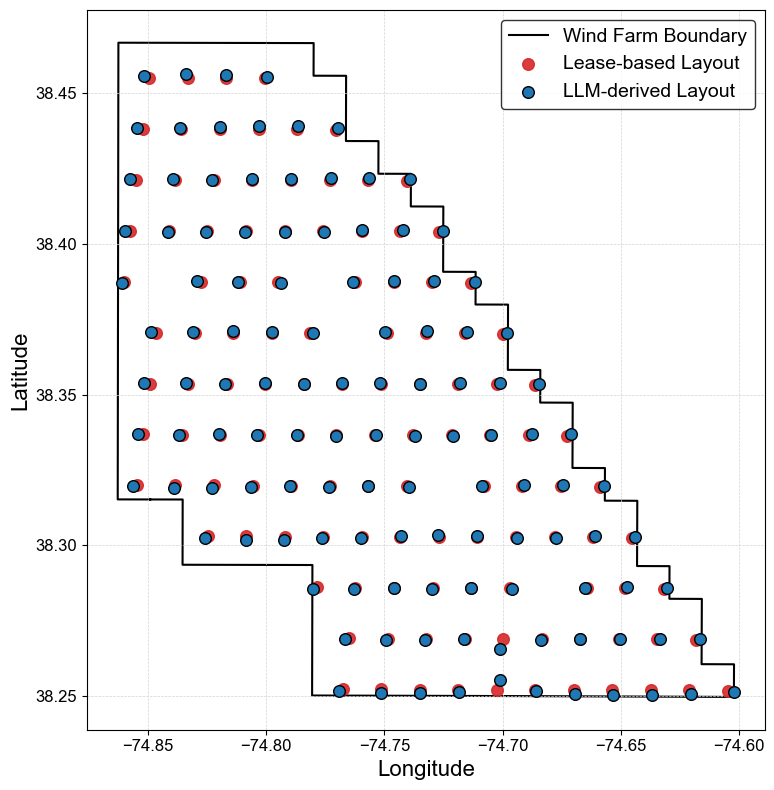

In [6]:
# Make sure you have pandas, scikit-learn, and matplotlib installed:
# pip install pandas scikit-learn matplotlib
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from pyproj import Proj, transform
from shapely import wkt
import matplotlib.pyplot as plt
import os

# --- Standalone Comparison of Optimized vs. Ground-Truth Layouts ---
# This script reads both the initial and final layouts from .txt files.

print("\n--- Generating Layout Comparison and Statistics ---")

# --- Define Key Physical & File Parameters ---
rotor_diameter = 240.0  # meters
min_spacing_m = 10 * rotor_diameter # 2400 meters

# File paths for the layouts and the boundary
ground_truth_file = 'project_folder/Wind/TopFarm/coordinates.txt'
optimized_coords_file = 'project_folder/Wind/Digital_Twin/Optimization_turbine_position/optimized_layout_coordinates.txt'
boundary_file = 'project_folder/Wind/TopFarm/wind farm coordinates.txt'


print(f"Using Rotor Diameter: {rotor_diameter} m")
print(f"Comparing ground-truth: '{os.path.basename(ground_truth_file)}'")
print(f"Against optimized layout: '{os.path.basename(optimized_coords_file)}'")

# --- 1. Load and Process Data ---
try:
    # Load all coordinate and boundary files
    ground_truth_latlon = np.loadtxt(ground_truth_file, delimiter=',')
    optimized_latlon = np.loadtxt(optimized_coords_file, delimiter=',')
    with open(boundary_file, 'r') as f:
        wkt_polygon = f.read().strip()
    print(f"Successfully loaded {len(ground_truth_latlon)} ground-truth and {len(optimized_latlon)} optimized positions.")

except FileNotFoundError as e:
    print(f"\n\nERROR: A required file was not found.")
    print(f"Details: {e}")
    exit()

# --- 2. Convert Coordinates from Lat/Lon to UTM ---
in_proj = Proj(init='epsg:4326')  # WGS 84 Latitude/Longitude
out_proj = Proj(init='epsg:32618') # UTM Zone 18N

ground_truth_utm = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in ground_truth_latlon])
optimized_utm = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in optimized_latlon])

# Convert boundary coordinates
polygon = wkt.loads(wkt_polygon)
boundary_coords = np.array(polygon.exterior.coords)
boundary_utm = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in boundary_coords])
print("Successfully converted all coordinates to UTM.")

# --- 3. Group Both Layouts into 13 Rows ---
# Process Optimized Layout
kmeans_opt = KMeans(n_clusters=13, random_state=0, n_init=10)
row_labels_opt = kmeans_opt.fit_predict(optimized_utm[:, 1].reshape(-1, 1))
df_optimized = pd.DataFrame({'Row_temp': row_labels_opt, 'x_utm': optimized_utm[:, 0], 'y_utm': optimized_utm[:, 1]})
row_y_means_opt = df_optimized.groupby('Row_temp')['y_utm'].mean().sort_values()
row_mapping_opt = {label: i + 1 for i, label in enumerate(row_y_means_opt.index)}
df_optimized['Row'] = df_optimized['Row_temp'].map(row_mapping_opt)
df_optimized_sorted = df_optimized[['Row', 'x_utm', 'y_utm']].sort_values(by=['Row', 'x_utm'])

# Process Ground-Truth Layout
kmeans_gt = KMeans(n_clusters=13, random_state=0, n_init=10)
row_labels_gt = kmeans_gt.fit_predict(ground_truth_utm[:, 1].reshape(-1, 1))
df_gt = pd.DataFrame({'Row_temp': row_labels_gt, 'x_utm_gt': ground_truth_utm[:, 0], 'y_utm_gt': ground_truth_utm[:, 1]})
row_y_means_gt = df_gt.groupby('Row_temp')['y_utm_gt'].mean().sort_values()
row_mapping_gt = {label: i + 1 for i, label in enumerate(row_y_means_gt.index)}
df_gt['Row'] = df_gt['Row_temp'].map(row_mapping_gt)
df_gt_sorted = df_gt[['Row', 'x_utm_gt', 'y_utm_gt']].sort_values(by=['Row', 'x_utm_gt'])

# --- 4. Merge DataFrames and Calculate Differences ---
df_optimized_sorted['turbine_in_row'] = df_optimized_sorted.groupby('Row').cumcount()
df_gt_sorted['turbine_in_row'] = df_gt_sorted.groupby('Row').cumcount()
comparison_df = pd.merge(df_optimized_sorted, df_gt_sorted, on=['Row', 'turbine_in_row'])

# Calculate absolute differences
comparison_df['x_diff_m'] = (comparison_df['x_utm'] - comparison_df['x_utm_gt']).abs()
comparison_df['y_diff_m'] = (comparison_df['y_utm'] - comparison_df['y_utm_gt']).abs()
comparison_df['x_diff_rd'] = comparison_df['x_diff_m'] / rotor_diameter
comparison_df['y_diff_rd'] = comparison_df['y_diff_m'] / rotor_diameter
comparison_df['x_diff_sp_pct'] = (comparison_df['x_diff_m'] / min_spacing_m) * 100
comparison_df['y_diff_sp_pct'] = (comparison_df['y_diff_m'] / min_spacing_m) * 100

# --- 5. Generate and Rename the Three Statistics DataFrames ---
stats_meters = comparison_df.groupby('Row').agg(
    x_diff_mean_m=('x_diff_m', 'mean'), x_diff_std_m=('x_diff_m', 'std'),
    y_diff_mean_m=('y_diff_m', 'mean'), y_diff_std_m=('y_diff_m', 'std')
).reset_index()
stats_meters.rename(columns={
    'x_diff_mean_m': 'Mean X-Deviation (m)', 'x_diff_std_m': 'Std Dev X-Deviation (m)',
    'y_diff_mean_m': 'Mean Y-Deviation (m)', 'y_diff_std_m': 'Std Dev Y-Deviation (m)'
}, inplace=True)

stats_rd = comparison_df.groupby('Row').agg(
    x_diff_mean_rd=('x_diff_rd', 'mean'), x_diff_std_rd=('x_diff_rd', 'std'),
    y_diff_mean_rd=('y_diff_rd', 'mean'), y_diff_std_rd=('y_diff_rd', 'std')
).reset_index()
stats_rd.rename(columns={
    'x_diff_mean_rd': 'Mean X-Deviation (RD)', 'x_diff_std_rd': 'Std Dev X-Deviation (RD)',
    'y_diff_mean_rd': 'Mean Y-Deviation (RD)', 'y_diff_std_rd': 'Std Dev Y-Deviation (RD)'
}, inplace=True)

stats_spacing = comparison_df.groupby('Row').agg(
    x_diff_mean_sp_pct=('x_diff_sp_pct', 'mean'), x_diff_std_sp_pct=('x_diff_sp_pct', 'std'),
    y_diff_mean_sp_pct=('y_diff_sp_pct', 'mean'), y_diff_std_sp_pct=('y_diff_sp_pct', 'std')
).reset_index()
stats_spacing.rename(columns={
    'x_diff_mean_sp_pct': 'Mean X-Deviation (% of Min. Spacing)', 'x_diff_std_sp_pct': 'Std Dev X-Deviation (% of Min. Spacing)',
    'y_diff_mean_sp_pct': 'Mean Y-Deviation (% of Min. Spacing)', 'y_diff_std_sp_pct': 'Std Dev Y-Deviation (% of Min. Spacing)'
}, inplace=True)

# --- 6. Display the Results ---
print("\n\n--- Final Optimized Turbine Coordinates by Row ---")
print(df_optimized_sorted[['Row', 'x_utm', 'y_utm']].to_string(index=False, float_format="%.2f"))

print("\n\n--- Table 1: Positional Deviation (in Meters) ---")
print(stats_meters.to_string(index=False, float_format="%.2f"))

print("\n\n--- Table 2: Positional Deviation Normalized by Rotor Diameter (RD) ---")
print(stats_rd.to_string(index=False, float_format="%.3f"))

print("\n\n--- Table 3: Positional Deviation as a Percentage of Minimum Spacing (10D = 2400m) ---")
print(stats_spacing.to_string(index=False, float_format="%.2f"))

# --- 7. Calculate and Display Overall Statistics ---
print("\n\n--- Overall Statistics Across All Turbines ---")

overall_meters_mean_x = comparison_df['x_diff_m'].mean()
overall_meters_std_x = comparison_df['x_diff_m'].std()
overall_meters_mean_y = comparison_df['y_diff_m'].mean()
overall_meters_std_y = comparison_df['y_diff_m'].std()
print("\nMetrics in Meters:")
print(f"  Overall Mean X-Deviation: {overall_meters_mean_x:.2f} m")
print(f"  Overall Std Dev X-Deviation: {overall_meters_std_x:.2f} m")
print(f"  Overall Mean Y-Deviation: {overall_meters_mean_y:.2f} m")
print(f"  Overall Std Dev Y-Deviation: {overall_meters_std_y:.2f} m")

overall_rd_mean_x = comparison_df['x_diff_rd'].mean()
overall_rd_std_x = comparison_df['x_diff_rd'].std()
overall_rd_mean_y = comparison_df['y_diff_rd'].mean()
overall_rd_std_y = comparison_df['y_diff_rd'].std()
print("\nMetrics Normalized by Rotor Diameter (RD):")
print(f"  Overall Mean X-Deviation: {overall_rd_mean_x:.3f} RD")
print(f"  Overall Std Dev X-Deviation: {overall_rd_std_x:.3f} RD")
print(f"  Overall Mean Y-Deviation: {overall_rd_mean_y:.3f} RD")
print(f"  Overall Std Dev Y-Deviation: {overall_rd_std_y:.3f} RD")

overall_sp_mean_x = comparison_df['x_diff_sp_pct'].mean()
overall_sp_std_x = comparison_df['x_diff_sp_pct'].std()
overall_sp_mean_y = comparison_df['y_diff_sp_pct'].mean()
overall_sp_std_y = comparison_df['y_diff_sp_pct'].std()
print("\nMetrics as a Percentage of Minimum Spacing:")
print(f"  Overall Mean X-Deviation: {overall_sp_mean_x:.2f}%")
print(f"  Overall Std Dev X-Deviation: {overall_sp_std_x:.2f}%")
print(f"  Overall Mean Y-Deviation: {overall_sp_mean_y:.2f}%")
print(f"  Overall Std Dev Y-Deviation: {overall_sp_std_y:.2f}%")

# --- 8. Generate Comparison Plot ---
print("\nGenerating publication-quality plot...")

# Set font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'

fig, ax = plt.subplots(figsize=(10, 8))

# Plot the wind farm boundary using original Lat/Lon coordinates
ax.plot(boundary_coords[:, 0], boundary_coords[:, 1], color='black', linestyle='-', linewidth=1.5, label='Wind Farm Boundary', zorder=1)

# Plot the ground-truth (Lease-based) positions using Lat/Lon
ax.scatter(ground_truth_latlon[:, 0], ground_truth_latlon[:, 1], c='#d62728', marker='o', s=70, label='Lease-based Layout', alpha=0.9, zorder=2)

# Plot the final optimized positions using Lat/Lon
ax.scatter(optimized_latlon[:, 0], optimized_latlon[:, 1], c='#1f77b4', marker='o', s=70, edgecolor='black', linewidth=1, label='LLM-derived Layout', zorder=3)

# ax.set_title('Wind Turbine Layout Optimization', fontsize=20, pad=15)
ax.set_xlabel('Longitude', fontsize=16)
ax.set_ylabel('Latitude', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)

# Calculate aspect ratio for a geographically correct plot
center_lat = np.mean(ground_truth_latlon[:, 1])
aspect_ratio = 1 / np.cos(np.radians(center_lat))
ax.set_aspect(aspect_ratio, adjustable='box')

legend = ax.legend(fontsize=14, loc='best')
legend.get_frame().set_edgecolor('black')

ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='lightgray')

fig.tight_layout()
plt.show()


Generating publication-quality plot...


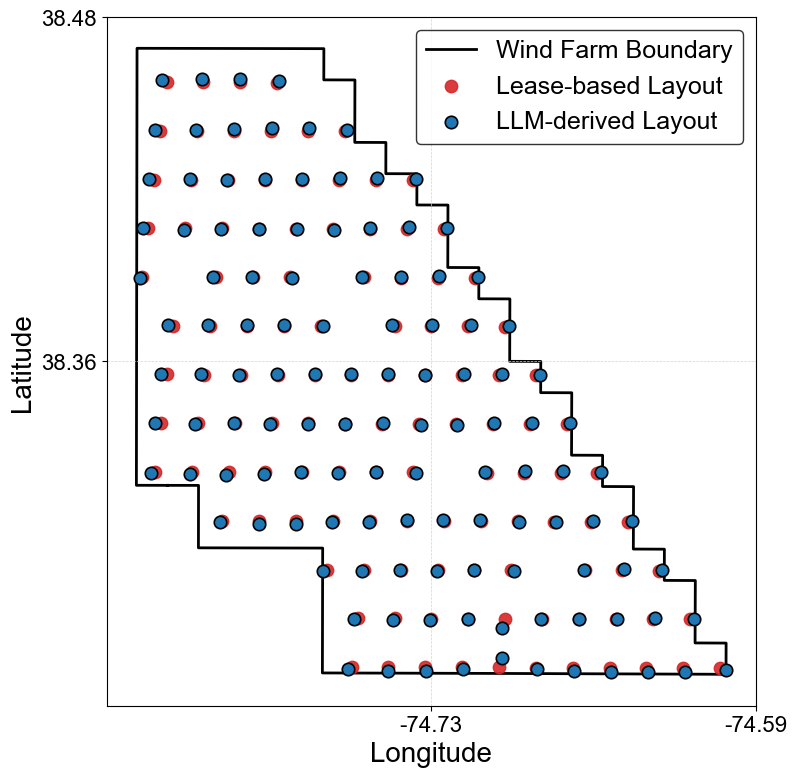

In [5]:
# --- 8. Generate Comparison Plot ---
print("\nGenerating publication-quality plot...")

# Set font to Arial and increase font sizes
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['font.size'] = 14 # Base font size

fig, ax = plt.subplots(figsize=(10, 8))

# Plot the wind farm boundary using original Lat/Lon coordinates
ax.plot(boundary_coords[:, 0], boundary_coords[:, 1], color='black', linestyle='-', linewidth=2, label='Wind Farm Boundary', zorder=1)

# Plot the ground-truth (Lease-based) positions using Lat/Lon
ax.scatter(ground_truth_latlon[:, 0], ground_truth_latlon[:, 1], c='#d62728', marker='o', s=80, label='Lease-based Layout', alpha=0.9, zorder=2)

# Plot the final optimized positions using Lat/Lon
ax.scatter(optimized_latlon[:, 0], optimized_latlon[:, 1], c='#1f77b4', marker='o', s=80, edgecolor='black', linewidth=1.2, label='LLM-derived Layout', zorder=3)

# ax.set_title('Wind Turbine Layout Comparison', fontsize=24, pad=20)
ax.set_xlabel('Longitude', fontsize=20)
ax.set_ylabel('Latitude', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)

# Calculate aspect ratio for a geographically correct plot
center_lat = np.mean(ground_truth_latlon[:, 1])
aspect_ratio = 1 / np.cos(np.radians(center_lat))
ax.set_aspect(aspect_ratio, adjustable='box')

# --- Customize Axis Ticks ---
# Get the current limits of the plot
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()

# Set exactly two ticks: the middle and the end value
ax.set_xticks([(x_lim[0] + x_lim[1]) / 2, x_lim[1]])
ax.set_yticks([(y_lim[0] + y_lim[1]) / 2, y_lim[1]])

# Format the tick labels to have fewer decimal places for a cleaner look
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))


legend = ax.legend(fontsize=18, loc='best')
legend.get_frame().set_edgecolor('black')

ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='lightgray')

fig.tight_layout()
plt.show()


Generating publication-quality plot...


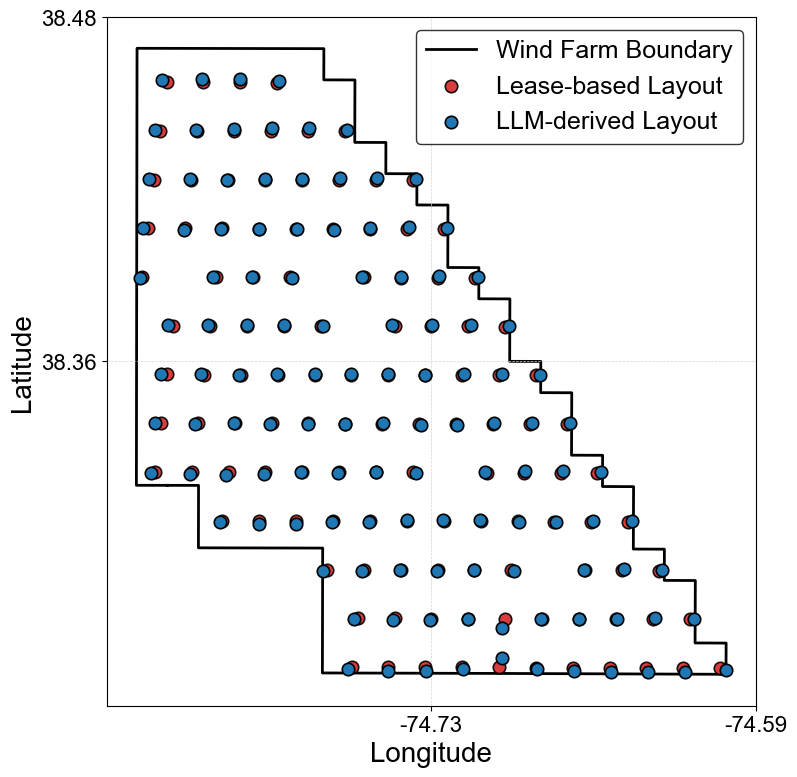

In [6]:
# --- 8. Generate Comparison Plot ---
print("\nGenerating publication-quality plot...")

# Set font to Arial and increase font sizes
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['font.size'] = 14 # Base font size

fig, ax = plt.subplots(figsize=(10, 8))

# Plot the wind farm boundary using original Lat/Lon coordinates
ax.plot(boundary_coords[:, 0], boundary_coords[:, 1], color='black', linestyle='-', linewidth=2, label='Wind Farm Boundary', zorder=1)

# Plot the ground-truth (Lease-based) positions using Lat/Lon with a black edge
ax.scatter(ground_truth_latlon[:, 0], ground_truth_latlon[:, 1], c='#d62728', marker='o', s=80, label='Lease-based Layout', alpha=0.9, zorder=2, edgecolor='black', linewidth=1.2)

# Plot the final optimized positions using Lat/Lon
ax.scatter(optimized_latlon[:, 0], optimized_latlon[:, 1], c='#1f77b4', marker='o', s=80, edgecolor='black', linewidth=1.2, label='LLM-derived Layout', zorder=3)

# ax.set_title('Wind Turbine Layout Comparison', fontsize=24, pad=20)
ax.set_xlabel('Longitude', fontsize=20)
ax.set_ylabel('Latitude', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)

# Calculate aspect ratio for a geographically correct plot
center_lat = np.mean(ground_truth_latlon[:, 1])
aspect_ratio = 1 / np.cos(np.radians(center_lat))
ax.set_aspect(aspect_ratio, adjustable='box')

# --- Customize Axis Ticks ---
# Get the current limits of the plot
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()

# Set exactly two ticks: the middle and the end value
ax.set_xticks([(x_lim[0] + x_lim[1]) / 2, x_lim[1]])
ax.set_yticks([(y_lim[0] + y_lim[1]) / 2, y_lim[1]])

# Format the tick labels to have fewer decimal places for a cleaner look
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))


legend = ax.legend(fontsize=18, loc='best')
legend.get_frame().set_edgecolor('black')

ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='lightgray')

fig.tight_layout()
plt.show()


Generating publication-quality plot...


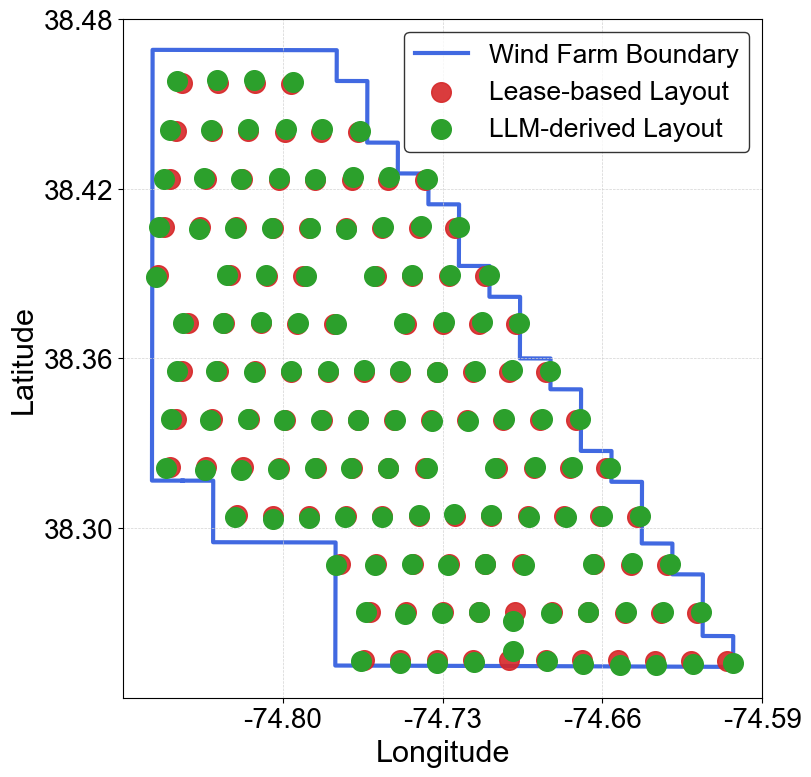

In [12]:
# --- 8. Generate Comparison Plot ---
print("\nGenerating publication-quality plot...")

# Set font to Arial and increase font sizes
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['font.size'] = 14 # Base font size

fig, ax = plt.subplots(figsize=(10, 8))

# Plot the wind farm boundary in a lighter, professional blue
ax.plot(boundary_coords[:, 0], boundary_coords[:, 1], color='royalblue', linestyle='-', linewidth=3, label='Wind Farm Boundary', zorder=1)

# Plot the ground-truth (Lease-based) positions without black edges
ax.scatter(ground_truth_latlon[:, 0], ground_truth_latlon[:, 1], c='#d62728', marker='o', s=200, label='Lease-based Layout', alpha=0.9, zorder=2)

# Plot the final optimized positions in green
ax.scatter(optimized_latlon[:, 0], optimized_latlon[:, 1], c='#2ca02c', marker='o', s=200, label='LLM-derived Layout', zorder=3)

# ax.set_title('Wind Turbine Layout Comparison', fontsize=24, pad=20)
ax.set_xlabel('Longitude', fontsize=22)
ax.set_ylabel('Latitude', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)

# Calculate aspect ratio for a geographically correct plot
center_lat = np.mean(ground_truth_latlon[:, 1])
aspect_ratio = 1 / np.cos(np.radians(center_lat))
ax.set_aspect(aspect_ratio, adjustable='box')

# --- Customize Axis Ticks ---
# Get the current limits of the plot
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()

# Generate 5 evenly spaced ticks and use the last 4 to avoid clashing at the origin
x_ticks = np.linspace(x_lim[0], x_lim[1], 5)
y_ticks = np.linspace(y_lim[0], y_lim[1], 5)
ax.set_xticks(x_ticks[1:])
ax.set_yticks(y_ticks[1:])


# Format the tick labels to have fewer decimal places for a cleaner look
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))


legend = ax.legend(fontsize=19, loc='best')
legend.get_frame().set_edgecolor('black')

ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='lightgray')

fig.tight_layout()
plt.show()


In [8]:
# # Make sure you have matplotlib installed: pip install matplotlib
# import matplotlib.pyplot as plt
# from shapely.geometry import Point, Polygon
# from shapely.ops import nearest_points
# from pyproj import Proj, transform
# import numpy as np
# import os

# # --- Post-Optimization Constraint Enforcement and Visualization ---

# print("\n--- Enforcing All Constraints Post-Optimization ---")

# # 1. Get the final optimized coordinates in UTM from the optimization state
# #    'state' is the dictionary returned by tf.optimize()
# #    We make a copy to modify it.
# corrected_x = np.copy(state['x'])
# corrected_y = np.copy(state['y'])
# n_wt = len(corrected_x)

# # 2. Get necessary parameters defined in your main script
# #    (This assumes they are available in the global scope)
# min_spacing_m = 10 * rotor_diameter 
# boundary_polygon_utm = Polygon(boundary)

# # 3. Start the iterative correction loop
# max_iter = 50 # Safety break to prevent infinite loops
# for iteration in range(max_iter):
#     print(f"Correction Iteration: {iteration + 1}")
#     violations_found = False

#     # --- Part A: Enforce Spacing Constraint ---
#     for i in range(n_wt):
#         for j in range(i + 1, n_wt):
#             # Calculate distance between turbine i and j
#             dx = corrected_x[j] - corrected_x[i]
#             dy = corrected_y[j] - corrected_y[i]
#             dist = np.sqrt(dx**2 + dy**2)

#             # If they are too close, push them apart
#             if dist < min_spacing_m:
#                 violations_found = True
                
#                 # Calculate the overlap distance
#                 overlap = min_spacing_m - dist
                
#                 # Push both turbines away from each other by half the overlap
#                 move_dist = overlap / 2.0
#                 corrected_x[i] -= move_dist * (dx / dist)
#                 corrected_y[i] -= move_dist * (dy / dist)
#                 corrected_x[j] += move_dist * (dx / dist)
#                 corrected_y[j] += move_dist * (dy / dist)

#     # --- Part B: Enforce Boundary Constraint ---
#     boundary_violations = 0
#     for i in range(n_wt):
#         turbine_point = Point(corrected_x[i], corrected_y[i])
#         if not boundary_polygon_utm.contains(turbine_point):
#             violations_found = True
#             boundary_violations += 1
            
#             # Project the point back to the nearest spot on the boundary
#             _, nearest_point_on_boundary = nearest_points(turbine_point, boundary_polygon_utm.boundary)
#             corrected_x[i] = nearest_point_on_boundary.x
#             corrected_y[i] = nearest_point_on_boundary.y
            
#     if boundary_violations > 0:
#         print(f"  - Corrected {boundary_violations} boundary violations.")

#     # If a full pass is made with no violations, the layout is clean.
#     if not violations_found:
#         print("No violations found. Layout is clean.")
#         break
        
#     if iteration == max_iter - 1:
#         print("Warning: Max correction iterations reached. Layout may still have violations.")


# # 4. Convert the final, corrected UTM coordinates back to Latitude/Longitude
# in_proj = Proj(init='epsg:4326')
# out_proj = Proj(init='epsg:32618') # Your UTM Zone 18N
# corrected_coords_latlon = [transform(out_proj, in_proj, x, y) for x, y in zip(corrected_x, corrected_y)]

# # 5. Save the final, guaranteed-in-boundary coordinates to a file
# final_output_file = 'final_corrected_coordinates.txt'
# np.savetxt(final_output_file, corrected_coords_latlon, delimiter=",", fmt="%.15f")
# print(f"Final, fully-corrected coordinates saved to: {os.path.abspath(final_output_file)}")


# # --- 6. Plot the results for visual verification (Publication Quality with Color) ---
# print("Generating publication-quality plot...")

# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman']
# plt.rcParams['mathtext.fontset'] = 'stix'

# fig, ax = plt.subplots(figsize=(10, 8))

# boundary_plot_x, boundary_plot_y = boundary_polygon_utm.exterior.xy
# ax.plot(boundary_plot_x, boundary_plot_y, color='black', linestyle='-', linewidth=1.5, label='Wind Farm Boundary', zorder=1)

# # Plot initial positions as red dots
# ax.scatter(x0, y0, c='#d62728', marker='o', s=70, label='Initial Position', alpha=0.9, zorder=2)

# # Plot final positions as blue dots with a black edge
# ax.scatter(corrected_x, corrected_y, c='#1f77b4', marker='o', s=70, edgecolor='black', linewidth=1, label='Final Position', zorder=3)

# ax.set_title('Wind Turbine Layout Optimization', fontsize=20, pad=15)
# ax.set_xlabel('UTM Easting (m)', fontsize=16)
# ax.set_ylabel('UTM Northing (m)', fontsize=16)
# ax.tick_params(axis='both', which='major', labelsize=12)

# legend = ax.legend(fontsize=14, loc='best')
# legend.get_frame().set_edgecolor('black')

# ax.set_aspect('equal', adjustable='box')
# ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='lightgray')

# fig.tight_layout()
# plt.show()

In [146]:
# # Make sure you have pandas and scikit-learn installed:
# # pip install pandas scikit-learn
# import pandas as pd
# import numpy as np
# from sklearn.cluster import KMeans
# from pyproj import Proj, transform

# # --- Complete Comparison of Optimized vs. Ground-Truth Layouts ---
# # This script is now standalone and reads both layouts from files.

# print("\n--- Generating Raw and Normalized Comparison DataFrames ---")

# # --- Define Key Physical Parameters ---
# rotor_diameter = 240.0  # meters
# min_spacing_m = 10 * rotor_diameter # 2400 meters

# print(f"Using Rotor Diameter: {rotor_diameter} m")
# print(f"Using Minimum Spacing: {min_spacing_m} m")

# # --- 1. Load and Process the OPTIMIZED Layout Data ---
# # This section now reads the final coordinates directly from the specified file.
# optimized_coords_file = 'project_folder/Wind/Digital_Twin/Optimization_turbine_position/final_corrected_coordinates.txt'

# try:
#     optimized_latlon = np.loadtxt(optimized_coords_file, delimiter=',')
#     print(f"Successfully loaded {len(optimized_latlon)} optimized turbine coordinates.")
# except FileNotFoundError:
#     print(f"\n\nERROR: The optimized coordinates file was not found at:")
#     print(f"'{optimized_coords_file}'")
#     print("Please ensure the file exists from a previous optimization run.")
#     exit()

# # Convert optimized coordinates from Lat/Lon (EPSG:4326) to UTM (EPSG:32618)
# in_proj = Proj(init='epsg:4326')
# out_proj = Proj(init='epsg:32618')
# optimized_utm = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in optimized_latlon])
# corrected_x = optimized_utm[:, 0]
# corrected_y = optimized_utm[:, 1]

# # Group optimized turbines into 13 rows using KMeans clustering
# kmeans = KMeans(n_clusters=13, random_state=0, n_init=10)
# row_labels = kmeans.fit_predict(optimized_utm[:, 1].reshape(-1, 1))

# # Create the 'final_df' DataFrame for the optimized layout
# final_df = pd.DataFrame({
#     'Row_temp': row_labels,
#     'x_utm': corrected_x,
#     'y_utm': corrected_y
# })
# row_y_means = final_df.groupby('Row_temp')['y_utm'].mean().sort_values()
# row_mapping = {label: i + 1 for i, label in enumerate(row_y_means.index)}
# final_df['Row'] = final_df['Row_temp'].map(row_mapping)
# final_df = final_df.drop(columns=['Row_temp'])
# print("Successfully processed optimized layout data.")


# # --- 2. Load and Process GROUND-TRUTH Data ---
# ground_truth_file = 'project_folder/Wind/TopFarm/coordinates.txt'

# try:
#     ground_truth_latlon = np.loadtxt(ground_truth_file, delimiter=',')
#     print(f"Successfully loaded {len(ground_truth_latlon)} ground-truth turbine coordinates.")
# except FileNotFoundError:
#     print(f"Error: Ground-truth file not found at '{ground_truth_file}'")
#     exit()

# ground_truth_utm = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in ground_truth_latlon])
# print("Successfully processed ground-truth layout data.")

# # --- 3. Group Ground-Truth Turbines into 13 Rows ---
# kmeans_gt = KMeans(n_clusters=13, random_state=0, n_init=10)
# row_labels_gt = kmeans_gt.fit_predict(ground_truth_utm[:, 1].reshape(-1, 1))
# df_gt = pd.DataFrame({'x_utm_gt': ground_truth_utm[:, 0], 'y_utm_gt': ground_truth_utm[:, 1], 'preliminary_row': row_labels_gt})
# row_y_means_gt = df_gt.groupby('preliminary_row')['y_utm_gt'].mean().sort_values()
# row_mapping_gt = {label: i + 1 for i, label in enumerate(row_y_means_gt.index)}
# df_gt['Row'] = df_gt['preliminary_row'].map(row_mapping_gt)
# df_gt_sorted = df_gt[['Row', 'x_utm_gt', 'y_utm_gt']].sort_values(by=['Row', 'x_utm_gt'])

# # --- 4. Merge DataFrames and Calculate Differences ---
# final_df_sorted = final_df.sort_values(by=['Row', 'x_utm'])
# final_df_sorted['turbine_in_row'] = final_df_sorted.groupby('Row').cumcount()
# df_gt_sorted['turbine_in_row'] = df_gt_sorted.groupby('Row').cumcount()
# comparison_df = pd.merge(final_df_sorted, df_gt_sorted, on=['Row', 'turbine_in_row'])

# # Calculate absolute differences
# comparison_df['x_diff_m'] = (comparison_df['x_utm'] - comparison_df['x_utm_gt']).abs()
# comparison_df['y_diff_m'] = (comparison_df['y_utm'] - comparison_df['y_utm_gt']).abs()
# comparison_df['x_diff_rd'] = comparison_df['x_diff_m'] / rotor_diameter
# comparison_df['y_diff_rd'] = comparison_df['y_diff_m'] / rotor_diameter
# comparison_df['x_diff_sp_pct'] = (comparison_df['x_diff_m'] / min_spacing_m) * 100
# comparison_df['y_diff_sp_pct'] = (comparison_df['y_diff_m'] / min_spacing_m) * 100

# # --- 5. Generate and Rename the Three Statistics DataFrames ---
# stats_meters = comparison_df.groupby('Row').agg(
#     x_diff_mean_m=('x_diff_m', 'mean'), x_diff_std_m=('x_diff_m', 'std'),
#     y_diff_mean_m=('y_diff_m', 'mean'), y_diff_std_m=('y_diff_m', 'std')
# ).reset_index()
# stats_meters.rename(columns={
#     'x_diff_mean_m': 'Mean X-Deviation (m)', 'x_diff_std_m': 'Std Dev X-Deviation (m)',
#     'y_diff_mean_m': 'Mean Y-Deviation (m)', 'y_diff_std_m': 'Std Dev Y-Deviation (m)'
# }, inplace=True)

# stats_rd = comparison_df.groupby('Row').agg(
#     x_diff_mean_rd=('x_diff_rd', 'mean'), x_diff_std_rd=('x_diff_rd', 'std'),
#     y_diff_mean_rd=('y_diff_rd', 'mean'), y_diff_std_rd=('y_diff_rd', 'std')
# ).reset_index()
# stats_rd.rename(columns={
#     'x_diff_mean_rd': 'Mean X-Deviation (RD)', 'x_diff_std_rd': 'Std Dev X-Deviation (RD)',
#     'y_diff_mean_rd': 'Mean Y-Deviation (RD)', 'y_diff_std_rd': 'Std Dev Y-Deviation (RD)'
# }, inplace=True)

# stats_spacing = comparison_df.groupby('Row').agg(
#     x_diff_mean_sp_pct=('x_diff_sp_pct', 'mean'), x_diff_std_sp_pct=('x_diff_sp_pct', 'std'),
#     y_diff_mean_sp_pct=('y_diff_sp_pct', 'mean'), y_diff_std_sp_pct=('y_diff_sp_pct', 'std')
# ).reset_index()
# stats_spacing.rename(columns={
#     'x_diff_mean_sp_pct': 'Mean X-Deviation (% of Min. Spacing)', 'x_diff_std_sp_pct': 'Std Dev X-Deviation (% of Min. Spacing)',
#     'y_diff_mean_sp_pct': 'Mean Y-Deviation (% of Min. Spacing)', 'y_diff_std_sp_pct': 'Std Dev Y-Deviation (% of Min. Spacing)'
# }, inplace=True)

# # --- 6. Display the Results ---
# print("\n\n--- Final Optimized Turbine Coordinates by Row ---")
# print(final_df_sorted[['Row', 'x_utm', 'y_utm']].to_string(index=False, float_format="%.2f"))

# print("\n\n--- Table 1: Positional Deviation (in Meters) ---")
# print(stats_meters.to_string(index=False, float_format="%.2f"))

# print("\n\n--- Table 2: Positional Deviation Normalized by Rotor Diameter (RD) ---")
# print(stats_rd.to_string(index=False, float_format="%.3f"))

# print("\n\n--- Table 3: Positional Deviation as a Percentage of Minimum Spacing (10D = 2400m) ---")
# print(stats_spacing.to_string(index=False, float_format="%.2f"))

# # --- 7. Calculate and Display Overall Statistics ---
# print("\n\n--- Overall Statistics Across All Turbines ---")

# overall_meters_mean_x = comparison_df['x_diff_m'].mean()
# overall_meters_std_x = comparison_df['x_diff_m'].std()
# overall_meters_mean_y = comparison_df['y_diff_m'].mean()
# overall_meters_std_y = comparison_df['y_diff_m'].std()
# print("\nMetrics in Meters:")
# print(f"  Overall Mean X-Deviation: {overall_meters_mean_x:.2f} m")
# print(f"  Overall Std Dev X-Deviation: {overall_meters_std_x:.2f} m")
# print(f"  Overall Mean Y-Deviation: {overall_meters_mean_y:.2f} m")
# print(f"  Overall Std Dev Y-Deviation: {overall_meters_std_y:.2f} m")

# overall_rd_mean_x = comparison_df['x_diff_rd'].mean()
# overall_rd_std_x = comparison_df['x_diff_rd'].std()
# overall_rd_mean_y = comparison_df['y_diff_rd'].mean()
# overall_rd_std_y = comparison_df['y_diff_rd'].std()
# print("\nMetrics Normalized by Rotor Diameter (RD):")
# print(f"  Overall Mean X-Deviation: {overall_rd_mean_x:.3f} RD")
# print(f"  Overall Std Dev X-Deviation: {overall_rd_std_x:.3f} RD")
# print(f"  Overall Mean Y-Deviation: {overall_rd_mean_y:.3f} RD")
# print(f"  Overall Std Dev Y-Deviation: {overall_rd_std_y:.3f} RD")

# overall_sp_mean_x = comparison_df['x_diff_sp_pct'].mean()
# overall_sp_std_x = comparison_df['x_diff_sp_pct'].std()
# overall_sp_mean_y = comparison_df['y_diff_sp_pct'].mean()
# overall_sp_std_y = comparison_df['y_diff_sp_pct'].std()
# print("\nMetrics as a Percentage of Minimum Spacing:")
# print(f"  Overall Mean X-Deviation: {overall_sp_mean_x:.2f}%")
# print(f"  Overall Std Dev X-Deviation: {overall_sp_std_x:.2f}%")
# print(f"  Overall Mean Y-Deviation: {overall_sp_mean_y:.2f}%")
# print(f"  Overall Std Dev Y-Deviation: {overall_sp_std_y:.2f}%")